# MY ATTEMPT AT THE SKILLS FIGURE USING RADAR CHART

# Figures. Skill Composition of Faster- and Slower-Growing Occupations

> **Status: Work in progress.**  
> This version is designed to follow the logic of the reference radar more closely: each axis is a **specific employer-requested skill**, and each plotted value is the **percent of job postings mentioning that skill**.

## Why this method

The reference figure states that values represent the **percent of postings with an identified skill within SOC**. That is a job-posting prevalence measure, not an O*NET importance score.

For that reason, this version uses **Lightcast job-posting skills as the primary source for the figure**.

O*NET is not used to choose the radar axes.

## Research question

Within each priority sector:

**Which specific skills appear more frequently in 2025 job postings for occupations projected to grow faster versus occupations projected to grow more slowly?**

Separate figures are produced for:

1. Healthcare and Social Assistance
2. Manufacturing
3. Construction
4. Semiconductors

## Data sources

### 2025 Staffing Pattern
Used to connect target industries (NAICS) to detailed occupations (SOC).

- Healthcare and Social Assistance = NAICS 62
- Manufacturing = NAICS 31–33
- Construction = NAICS 23
- Semiconductors = NAICS 334

Manufacturing includes NAICS 334. Semiconductors are also shown separately as a focused subset.

### OEO Occupational Projections
Used only to identify faster- and slower-growing occupations.

The primary figures use **long-term 2024–2034 projected percentage employment growth**.

### 2025 Lightcast Job Postings
Used to identify employer-requested skills.

The main radar uses **`SKILLS_NAME` only**. `SOFTWARE_SKILLS_NAME` is analyzed separately so product names such as Excel or Microsoft Office do not dominate the main skill story.

## How the radar skills are selected

The radar skills are **not manually chosen after viewing the results**.

For each sector:

1. Count the share of faster-growing and slower-growing postings that mention each Lightcast skill.
2. Count the number of distinct SOC occupations in the sector whose postings contain the skill.
3. Keep a skill only if it appears in at least **5% of postings** in either group and across at least **3 distinct SOCs**.
4. Calculate the absolute percentage-point difference between faster- and slower-growing postings.
5. Select the **8 eligible skills with the largest differences**.

This produces a sector-specific word bank that is common enough to be meaningful, observed directly in employer postings, and useful for distinguishing the two occupation groups.

## Radar measure

**Skill prevalence = postings mentioning the skill ÷ all postings in the selected occupation group.**

The radar therefore displays the **percent of 2025 Lightcast postings mentioning each specific skill**.

## Interpretation

The figures describe current employer-requested skills in occupations with different projected growth trajectories. They do not imply that a skill causes occupational growth and do not directly measure future skill demand.


In [1]:
# ============================================================
# 1. FILE PATHS + SETTINGS
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import ast
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 240)

# ------------------------------------------------------------
# INPUTS
# ------------------------------------------------------------

STAFFING_PATTERN_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\2025 Staffing Pattern (2).xlsx"
)

SHORT_TERM_OCCUPATION_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\occ_short_term (6).xlsx"
)

LONG_TERM_OCCUPATION_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\ltop-04-2024to2034 (7).xlsx"
)

LIGHTCAST_POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis"
    r"\Job Posting Data\raw_data\df_2016_2025.csv"
)

OUTPUT_FOLDER = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar"
)

OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_WORKBOOK = (
    OUTPUT_FOLDER
    / "Sector_Skills_Lightcast_Published.xlsx"
)

# ------------------------------------------------------------
# ANALYSIS SETTINGS
# ------------------------------------------------------------

POSTINGS_YEAR = 2025
TOP_N_OCCUPATIONS = 10
N_RADAR_SKILLS = 8

# Minimum prevalence for a skill to be considered meaningful.
MIN_GROUP_PREVALENCE = 0.05

# Skill must meet the threshold in at least this many sectors.
MIN_SOC_COVERAGE = 3

PRIMARY_HORIZON = "Long_Term_2024_2034"

CHUNK_SIZE = 100_000

STAFFING_AREATYPE = "01"
STAFFING_AREA = "000004"
STAFFING_OCCCLASS = "N"

SECTOR_ORDER = [
    "Healthcare and Social Assistance",
    "Manufacturing",
    "Construction",
    "Semiconductors",
]

SECTOR_NAICS_PREFIXES = {
    "Healthcare and Social Assistance": ["62"],
    "Manufacturing": ["31", "32", "33"],
    "Construction": ["23"],
    "Semiconductors": ["334"],
}

FASTER_COLOR = "#369992"
SLOWER_COLOR = "#CC6C20"

print("Output folder:")
print(OUTPUT_FOLDER)


Output folder:
G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar


In [2]:
# ============================================================
# 2. HELPERS
# ============================================================

def normalize_col(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).strip().lower()
    )


def clean_soc(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d{2})[-\s]?(\d{4})",
        str(value).strip()
    )

    if match:
        return (
            f"{match.group(1)}-"
            f"{match.group(2)}"
        )

    return np.nan


def is_detailed_soc(soc):

    return (
        pd.notna(soc)
        and not str(soc).endswith("-0000")
    )


def numeric_series(series):

    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip(),
        errors="coerce"
    )


def parse_skill_list(value):

    if pd.isna(value):
        return []

    text = str(value).strip()

    if text in {"", "[]", "nan", "None"}:
        return []

    try:

        parsed = ast.literal_eval(text)

        if isinstance(parsed, list):
            return [
                str(item).strip()
                for item in parsed
                if str(item).strip()
            ]

    except Exception:
        pass

    try:

        parsed = json.loads(text)

        if isinstance(parsed, list):
            return [
                str(item).strip()
                for item in parsed
                if str(item).strip()
            ]

    except Exception:
        pass

    return []


def clean_skill(skill):

    return (
        str(skill)
        .strip()
        .casefold()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )


def display_skill(skill):

    return (
        str(skill)
        .strip()
        .title()
    )


def matches_sector_naics(
    industry_code,
    prefixes
):

    if pd.isna(industry_code):
        return False

    text = str(
        industry_code
    ).strip()

    return any(
        text.startswith(prefix)
        for prefix in prefixes
    )


def choose_column(
    dataframe,
    patterns,
    required=True
):

    normalized = {
        column:
            normalize_col(column)
        for column in dataframe.columns
    }

    for pattern in patterns:

        target = normalize_col(pattern)

        for column, cleaned in normalized.items():

            if cleaned == target:
                return column

    for pattern in patterns:

        target = normalize_col(pattern)

        for column, cleaned in normalized.items():

            if target and target in cleaned:
                return column

    if required:
        raise KeyError(
            f"Could not identify column matching {patterns}."
        )

    return None


## 3. Define sector occupation universes

The 2025 staffing pattern links target industries to detailed SOC occupations.

Sector definitions:

- Healthcare and Social Assistance: NAICS 62
- Manufacturing: NAICS 31–33
- Construction: NAICS 23
- Semiconductors: NAICS 334

Manufacturing includes NAICS 334; Semiconductors are also analyzed separately as a focused subset.


In [3]:
# ============================================================
# 3. STAFFING PATTERN
# ============================================================

staff = pd.read_excel(
    STAFFING_PATTERN_FILE
)

staff.columns = [
    str(column).strip()
    for column in staff.columns
]

required_staff = [
    "areatype",
    "area",
    "indcode",
    "occclass",
    "occcd",
    "empl",
]

missing = [
    column
    for column in required_staff
    if column not in staff.columns
]

if missing:
    raise KeyError(
        f"Staffing pattern missing columns: {missing}"
    )

staff["areatype"] = (
    staff["areatype"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(2)
)

staff["area"] = (
    staff["area"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(6)
)

staff["indcode"] = (
    staff["indcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

staff["occclass"] = (
    staff["occclass"]
    .astype(str)
    .str.strip()
)

staff["SOC"] = (
    staff["occcd"]
    .map(clean_soc)
)

staff["Staffing_Employment"] = (
    numeric_series(
        staff["empl"]
    )
)

staff = staff[
    staff["areatype"].eq(
        STAFFING_AREATYPE
    )
    &
    staff["area"].eq(
        STAFFING_AREA
    )
    &
    staff["occclass"].eq(
        STAFFING_OCCCLASS
    )
    &
    staff["SOC"].notna()
    &
    staff["SOC"].map(
        is_detailed_soc
    )
].copy()

sector_soc_tables = {}

for sector in SECTOR_ORDER:

    prefixes = (
        SECTOR_NAICS_PREFIXES[
            sector
        ]
    )

    subset = staff[
        staff["indcode"].map(
            lambda value:
                matches_sector_naics(
                    value,
                    prefixes
                )
        )
    ].copy()

    subset = (
        subset
        .groupby(
            "SOC",
            as_index=False
        )
        .agg(
            Staffing_Employment=(
                "Staffing_Employment",
                "sum"
            )
        )
    )

    sector_soc_tables[
        sector
    ] = subset

    print(
        sector,
        "->",
        len(subset),
        "detailed SOCs"
    )


Healthcare and Social Assistance -> 373 detailed SOCs
Manufacturing -> 378 detailed SOCs
Construction -> 218 detailed SOCs
Semiconductors -> 184 detailed SOCs


## 4. Classify faster- and slower-growing occupations

Occupations are ranked within each sector using OEO projected percentage employment growth.

The main figures use the **long-term 2024–2034 projection horizon**.

The default selection is the 10 fastest-growing and 10 slowest-growing occupations. For smaller sectors, the largest possible non-overlapping groups are used.


In [4]:
# ============================================================
# 4. LOAD PROJECTIONS
# ============================================================

def find_projection_table(path):

    workbook = pd.ExcelFile(path)

    candidates = []

    for sheet in workbook.sheet_names:

        for header_row in range(12):

            try:

                dataframe = pd.read_excel(
                    path,
                    sheet_name=sheet,
                    header=header_row
                )

            except Exception:
                continue

            if dataframe.empty:
                continue

            normalized = {
                column:
                    normalize_col(column)
                for column in dataframe.columns
            }

            has_soc = any(
                (
                    "soc" in value
                    or "occupationcode" in value
                    or value in {"occcd", "occcode"}
                )
                for value in normalized.values()
            )

            has_growth = any(
                (
                    "growth" in value
                    or "percentchange" in value
                    or "pctchange" in value
                )
                for value in normalized.values()
            )

            score = (
                5 * has_soc
                + 3 * has_growth
            )

            if has_soc:

                candidates.append(
                    (
                        score,
                        sheet,
                        header_row,
                        dataframe,
                    )
                )

    if not candidates:
        raise ValueError(
            f"Could not identify projection table in {path}"
        )

    candidates.sort(
        key=lambda item: item[0],
        reverse=True
    )

    score, sheet, header_row, dataframe = candidates[0]

    print(
        path.name,
        "->",
        sheet,
        "header row",
        header_row + 1
    )

    return dataframe


def standardize_projection(
    dataframe,
    horizon
):

    soc_col = choose_column(
        dataframe,
        [
            "SOC",
            "SOC Code",
            "Occupation Code",
            "occcd",
        ]
    )

    title_col = choose_column(
        dataframe,
        [
            "Occupation Title",
            "Occupation",
            "Title",
        ],
        required=False
    )

    growth_col = choose_column(
        dataframe,
        [
            "Percent Change",
            "Percentage Change",
            "Growth Rate",
            "Percent Growth",
            "Pct Change",
        ],
        required=False
    )

    change_col = choose_column(
        dataframe,
        [
            "Numeric Change",
            "Employment Change",
            "Projected Change",
        ],
        required=False
    )

    normalized = {
        column:
            normalize_col(column)
        for column in dataframe.columns
    }

    employment_cols = [
        column
        for column, cleaned
        in normalized.items()
        if "employment" in cleaned
    ]

    base_col = (
        employment_cols[0]
        if len(employment_cols) >= 1
        else None
    )

    projected_col = (
        employment_cols[1]
        if len(employment_cols) >= 2
        else None
    )

    output = pd.DataFrame()

    output["SOC"] = (
        dataframe[
            soc_col
        ].map(clean_soc)
    )

    output["Occupation"] = (
        dataframe[
            title_col
        ].astype(str).str.strip()
        if title_col is not None
        else ""
    )

    output["Base_Employment"] = (
        numeric_series(
            dataframe[
                base_col
            ]
        )
        if base_col is not None
        else np.nan
    )

    output["Projected_Employment"] = (
        numeric_series(
            dataframe[
                projected_col
            ]
        )
        if projected_col is not None
        else np.nan
    )

    if change_col is not None:

        output["Numeric_Change"] = (
            numeric_series(
                dataframe[
                    change_col
                ]
            )
        )

    else:

        output["Numeric_Change"] = (
            output[
                "Projected_Employment"
            ]
            -
            output[
                "Base_Employment"
            ]
        )

    if growth_col is not None:

        output["Growth_Rate"] = (
            numeric_series(
                dataframe[
                    growth_col
                ]
            )
        )

    else:

        output["Growth_Rate"] = np.where(
            output[
                "Base_Employment"
            ] > 0,
            100
            * output[
                "Numeric_Change"
            ]
            / output[
                "Base_Employment"
            ],
            np.nan
        )

    output["Horizon"] = horizon

    return (
        output[
            output["SOC"].notna()
            &
            output["SOC"].map(
                is_detailed_soc
            )
        ]
        .drop_duplicates(
            "SOC"
        )
        .reset_index(
            drop=True
        )
    )


long_projection = standardize_projection(
    find_projection_table(
        LONG_TERM_OCCUPATION_FILE
    ),
    "Long-Term 2024–2034"
)

short_projection = standardize_projection(
    find_projection_table(
        SHORT_TERM_OCCUPATION_FILE
    ),
    "Short-Term 2025–2027"
)

projection_sets = {
    "Long_Term_2024_2034":
        long_projection,

    "Short_Term_2025_2027":
        short_projection,
}


ltop-04-2024to2034 (7).xlsx -> Occupation_Projections_24_34 header row 2
occ_short_term (6).xlsx -> OCC_Proj_ALL_25_27 header row 3


In [5]:
# ============================================================
# 5. SELECT FAST / SLOW OCCUPATIONS
# ============================================================

selected_occupation_tables = {}

for horizon_key, projections in projection_sets.items():

    for sector in SECTOR_ORDER:

        merged = (
            sector_soc_tables[
                sector
            ]
            .merge(
                projections,
                on="SOC",
                how="inner"
            )
        )

        merged = merged[
            merged[
                "Growth_Rate"
            ].notna()
        ].copy()

        if len(merged) < 2:
            continue

        n_each = min(
            TOP_N_OCCUPATIONS,
            len(merged) // 2
        )

        faster = (
            merged
            .sort_values(
                [
                    "Growth_Rate",
                    "Numeric_Change",
                ],
                ascending=[
                    False,
                    False,
                ]
            )
            .head(n_each)
            .copy()
        )

        slower_pool = merged[
            ~merged["SOC"].isin(
                faster["SOC"]
            )
        ].copy()

        slower = (
            slower_pool
            .sort_values(
                [
                    "Growth_Rate",
                    "Numeric_Change",
                ],
                ascending=[
                    True,
                    True,
                ]
            )
            .head(n_each)
            .copy()
        )

        faster["Growth_Group"] = "Faster-growing occupations"
        slower["Growth_Group"] = "Slower-growing occupations"

        selected = pd.concat(
            [
                faster,
                slower,
            ],
            ignore_index=True
        )

        selected_occupation_tables[
            (
                horizon_key,
                sector,
            )
        ] = selected

        print(
            sector,
            horizon_key,
            "->",
            len(faster),
            "faster /",
            len(slower),
            "slower"
        )


Healthcare and Social Assistance Long_Term_2024_2034 -> 10 faster / 10 slower
Manufacturing Long_Term_2024_2034 -> 10 faster / 10 slower
Construction Long_Term_2024_2034 -> 10 faster / 10 slower
Semiconductors Long_Term_2024_2034 -> 10 faster / 10 slower


## 6. Count specific Lightcast skills

Only `SKILLS_NAME` is used to select the radar axes. These are the specific employer-requested skills shown in the main figure.

`SOFTWARE_SKILLS_NAME` is counted separately and exported as a supporting table.

Within each posting, duplicate mentions of the same skill are counted once.


In [6]:
# ============================================================
# 6. LIGHTCAST 2025 POSTING SKILL COUNTS
# ============================================================

soc_to_targets = defaultdict(list)

for (horizon_key, sector), selected in selected_occupation_tables.items():
    if horizon_key != PRIMARY_HORIZON:
        continue

    for _, row in selected.iterrows():
        soc_to_targets[row["SOC"]].append(
            (
                sector,
                row["Growth_Group"],
            )
        )

needed_socs = set(soc_to_targets.keys())

posting_totals = Counter()
skill_posting_counts = Counter()
skill_soc_coverage = defaultdict(set)
software_posting_counts = Counter()

lightcast_columns = [
    "SOC_5",
    "YEAR",
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
]

for chunk_number, chunk in enumerate(
    pd.read_csv(
        LIGHTCAST_POSTINGS_FILE,
        usecols=lambda column: column in lightcast_columns,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    ),
    start=1,
):
    chunk["YEAR"] = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce",
    )

    chunk = chunk[
        chunk["YEAR"].eq(POSTINGS_YEAR)
    ].copy()

    if chunk.empty:
        continue

    chunk["SOC"] = chunk["SOC_5"].map(clean_soc)

    chunk = chunk[
        chunk["SOC"].isin(needed_socs)
    ].copy()

    if chunk.empty:
        continue

    for _, row in chunk.iterrows():
        soc = row["SOC"]

        general_skills = {
            clean_skill(skill)
            for skill in parse_skill_list(row.get("SKILLS_NAME"))
            if str(skill).strip()
        }

        software_skills = {
            clean_skill(skill)
            for skill in parse_skill_list(row.get("SOFTWARE_SKILLS_NAME"))
            if str(skill).strip()
        }

        for sector, growth_group in soc_to_targets.get(soc, []):
            posting_totals[(sector, growth_group)] += 1

            for skill in general_skills:
                skill_posting_counts[(sector, growth_group, skill)] += 1
                skill_soc_coverage[(sector, skill)].add(soc)

            for skill in software_skills:
                software_posting_counts[(sector, growth_group, skill)] += 1

    if chunk_number % 10 == 0:
        print(f"Processed Lightcast chunk {chunk_number}")

print("Finished reading Lightcast postings.")


Finished reading Lightcast postings.


## 7. Select sector-specific radar skills from the data

Every observed Lightcast general skill is evaluated separately within each sector.

A skill is eligible when:

- at least **5% of postings** in the faster- or slower-growing group mention it; and
- it appears in postings from at least **3 distinct SOC occupations** in the sector.

Among eligible skills, the notebook selects the **8 with the largest absolute faster-vs.-slower percentage-point difference**.

This favors skills that are both meaningful across the sector and visually informative, without hand-picking the final terms.


In [7]:
# ============================================================
# 7. BUILD SECTOR-SPECIFIC SKILL SELECTION TABLES
# ============================================================

skill_selection_tables = {}
radar_rows = []

for sector in SECTOR_ORDER:
    faster_group = "Faster-growing occupations"
    slower_group = "Slower-growing occupations"

    faster_total = posting_totals[(sector, faster_group)]
    slower_total = posting_totals[(sector, slower_group)]

    if faster_total == 0 or slower_total == 0:
        print(f"WARNING: no usable posting totals for {sector}")
        continue

    skills = {
        key[2]
        for key in skill_posting_counts
        if key[0] == sector
    }

    rows = []

    for skill in skills:
        faster_count = skill_posting_counts[(sector, faster_group, skill)]
        slower_count = skill_posting_counts[(sector, slower_group, skill)]

        faster_share = faster_count / faster_total
        slower_share = slower_count / slower_total
        difference = faster_share - slower_share
        max_share = max(faster_share, slower_share)
        soc_coverage = len(skill_soc_coverage[(sector, skill)])

        eligible = (
            max_share >= MIN_GROUP_PREVALENCE
            and soc_coverage >= MIN_SOC_COVERAGE
        )

        rows.append(
            {
                "Sector": sector,
                "Skill": display_skill(skill),
                "Skill_Raw": skill,
                "Faster-growing share": faster_share,
                "Slower-growing share": slower_share,
                "Difference": difference,
                "Absolute Difference": abs(difference),
                "Maximum Posting Share": max_share,
                "SOC Coverage": soc_coverage,
                "Eligible": eligible,
            }
        )

    comparison = pd.DataFrame(rows)

    if comparison.empty:
        continue

    comparison = comparison.sort_values(
        [
            "Eligible",
            "Absolute Difference",
            "Maximum Posting Share",
        ],
        ascending=[False, False, False],
    )

    selected = (
        comparison[comparison["Eligible"]]
        .head(N_RADAR_SKILLS)
        .copy()
    )

    selected["Selected for Radar"] = True

    comparison = comparison.merge(
        selected[["Skill_Raw", "Selected for Radar"]],
        on="Skill_Raw",
        how="left",
    )

    comparison["Selected for Radar"] = (
        comparison["Selected for Radar"].fillna(False)
    )

    skill_selection_tables[sector] = comparison

    print(f"\n{sector}")
    print("Selected Lightcast skills:")

    for _, row in selected.iterrows():
        print(
            f" - {row['Skill']} "
            f"(difference: {row['Difference']:+.1%}; "
            f"SOC coverage: {int(row['SOC Coverage'])})"
        )

        radar_rows.append(
            {
                "Sector": sector,
                "Skill": row["Skill"],
                "Faster-growing occupations": row["Faster-growing share"],
                "Slower-growing occupations": row["Slower-growing share"],
                "Difference": row["Difference"],
                "SOC Coverage": row["SOC Coverage"],
            }
        )

radar_data = pd.DataFrame(radar_rows)
display(radar_data)



Healthcare and Social Assistance
Selected Lightcast skills:
 - Data Entry (difference: -26.9%; SOC coverage: 14)
 - Detail Oriented (difference: -25.3%; SOC coverage: 17)
 - Leadership (difference: +14.8%; SOC coverage: 17)
 - Accounting (difference: -14.8%; SOC coverage: 11)
 - Nursing (difference: +13.0%; SOC coverage: 9)
 - Treatment Planning (difference: +12.1%; SOC coverage: 8)
 - Management (difference: +12.0%; SOC coverage: 18)
 - Behavioral Health (difference: +11.0%; SOC coverage: 6)

Manufacturing
Selected Lightcast skills:
 - Leadership (difference: +23.8%; SOC coverage: 15)
 - Data Entry (difference: -23.7%; SOC coverage: 11)
 - Detail Oriented (difference: -18.9%; SOC coverage: 15)
 - Management (difference: +18.5%; SOC coverage: 16)
 - Planning (difference: +13.2%; SOC coverage: 12)
 - Accounting (difference: -11.4%; SOC coverage: 8)
 - Scheduling (difference: +11.1%; SOC coverage: 13)
 - Communication (difference: +10.8%; SOC coverage: 15)

Construction
Selected Lightca

,Sector,Skill,Faster-growing occupations,Slower-growing occupations,Difference,SOC Coverage
0,Healthcare and Social Assistance,Data Entry,0.021957,0.291304,-0.269348,14
1,Healthcare and Social Assistance,Detail Oriented,0.092745,0.345652,-0.252907,17
2,Healthcare and Social Assistance,Leadership,0.236431,0.088043,0.148387,17
3,Healthcare and Social Assistance,Accounting,0.021957,0.169565,-0.147608,11
4,Healthcare and Social Assistance,Nursing,0.135254,0.005435,0.129819,9
5,Healthcare and Social Assistance,Treatment Planning,0.123309,0.002174,0.121135,8
6,Healthcare and Social Assistance,Management,0.274723,0.154348,0.120376,18
7,Healthcare and Social Assistance,Behavioral Health,0.111540,0.001087,0.110454,6
8,Manufacturing,Leadership,0.298559,0.060606,0.237953,15
9,Manufacturing,Data Entry,0.036605,0.273850,-0.237245,11


In [8]:
# ============================================================
# 8. SKILL-SELECTION QA SUMMARY
# ============================================================

qa_rows = []

for sector, table in skill_selection_tables.items():
    qa_rows.append(
        {
            "Sector": sector,
            "Candidate Skills": len(table),
            "Eligible Skills": int(table["Eligible"].sum()),
            "Selected Radar Skills": int(table["Selected for Radar"].sum()),
            "Minimum Posting Share": MIN_GROUP_PREVALENCE,
            "Minimum SOC Coverage": MIN_SOC_COVERAGE,
        }
    )

skill_selection_qa = pd.DataFrame(qa_rows)
display(skill_selection_qa)


,Sector,Candidate Skills,Eligible Skills,Selected Radar Skills,Minimum Posting Share,Minimum SOC Coverage
0,Healthcare and Social Assistance,5881,68,8,0.05,3
1,Manufacturing,6044,81,8,0.05,3
2,Construction,5877,85,8,0.05,3
3,Semiconductors,7247,70,8,0.05,3


## 9. Radar data

The radar values are the raw **share of 2025 Lightcast postings mentioning each selected skill**.

Each sector has its own data-selected skill axes because the goal is to describe that sector clearly rather than force all four sectors into the same vocabulary.


In [9]:
# ============================================================
# 9. RADAR DATA
# ============================================================

display(radar_data)


,Sector,Skill,Faster-growing occupations,Slower-growing occupations,Difference,SOC Coverage
0,Healthcare and Social Assistance,Data Entry,0.021957,0.291304,-0.269348,14
1,Healthcare and Social Assistance,Detail Oriented,0.092745,0.345652,-0.252907,17
2,Healthcare and Social Assistance,Leadership,0.236431,0.088043,0.148387,17
3,Healthcare and Social Assistance,Accounting,0.021957,0.169565,-0.147608,11
4,Healthcare and Social Assistance,Nursing,0.135254,0.005435,0.129819,9
5,Healthcare and Social Assistance,Treatment Planning,0.123309,0.002174,0.121135,8
6,Healthcare and Social Assistance,Management,0.274723,0.154348,0.120376,18
7,Healthcare and Social Assistance,Behavioral Health,0.111540,0.001087,0.110454,6
8,Manufacturing,Leadership,0.298559,0.060606,0.237953,15
9,Manufacturing,Data Entry,0.036605,0.273850,-0.237245,11


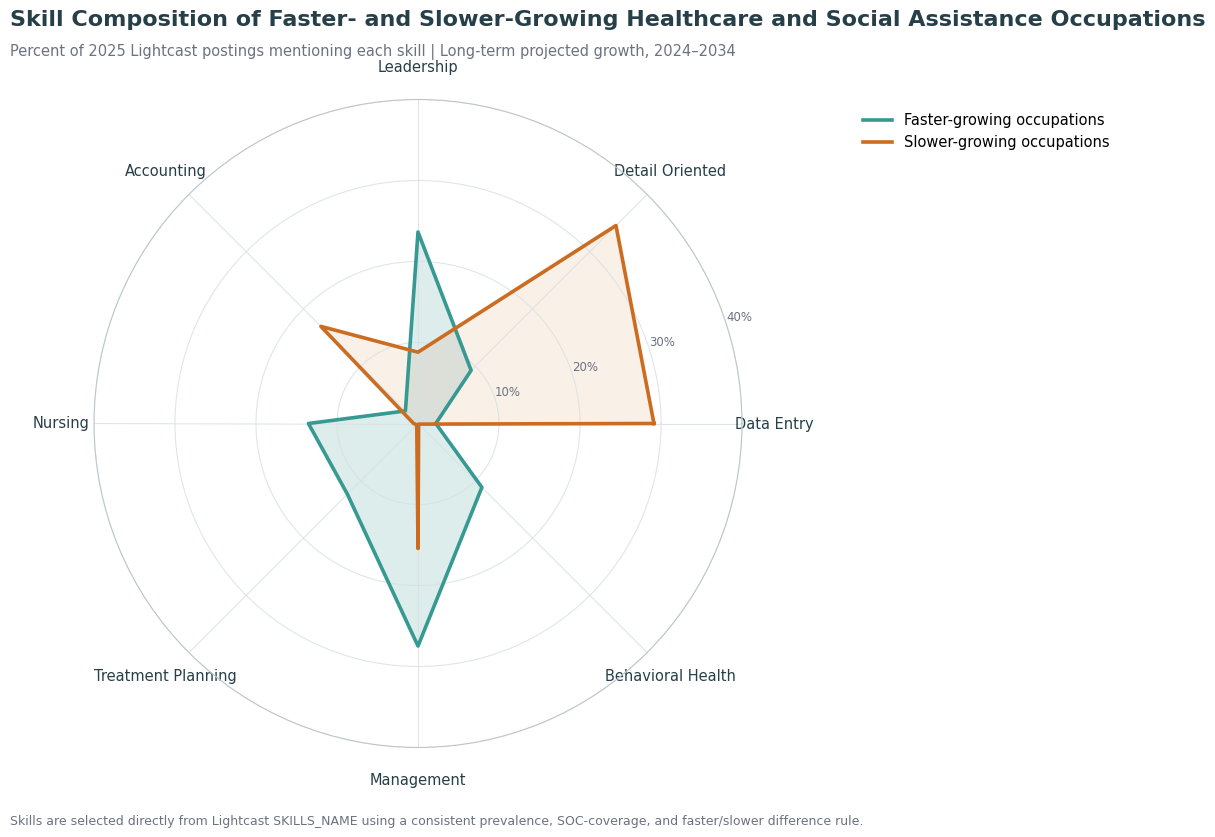

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Healthcare_and_Social_Assistance.png


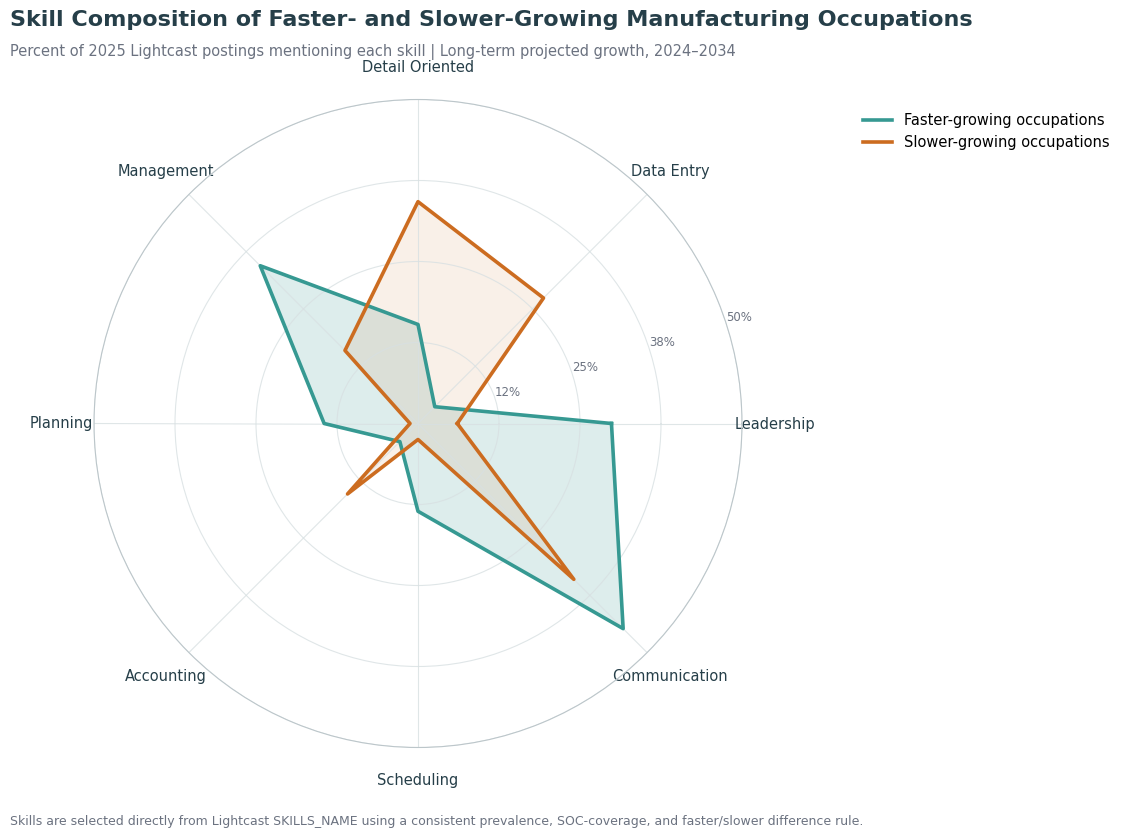

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Manufacturing.png


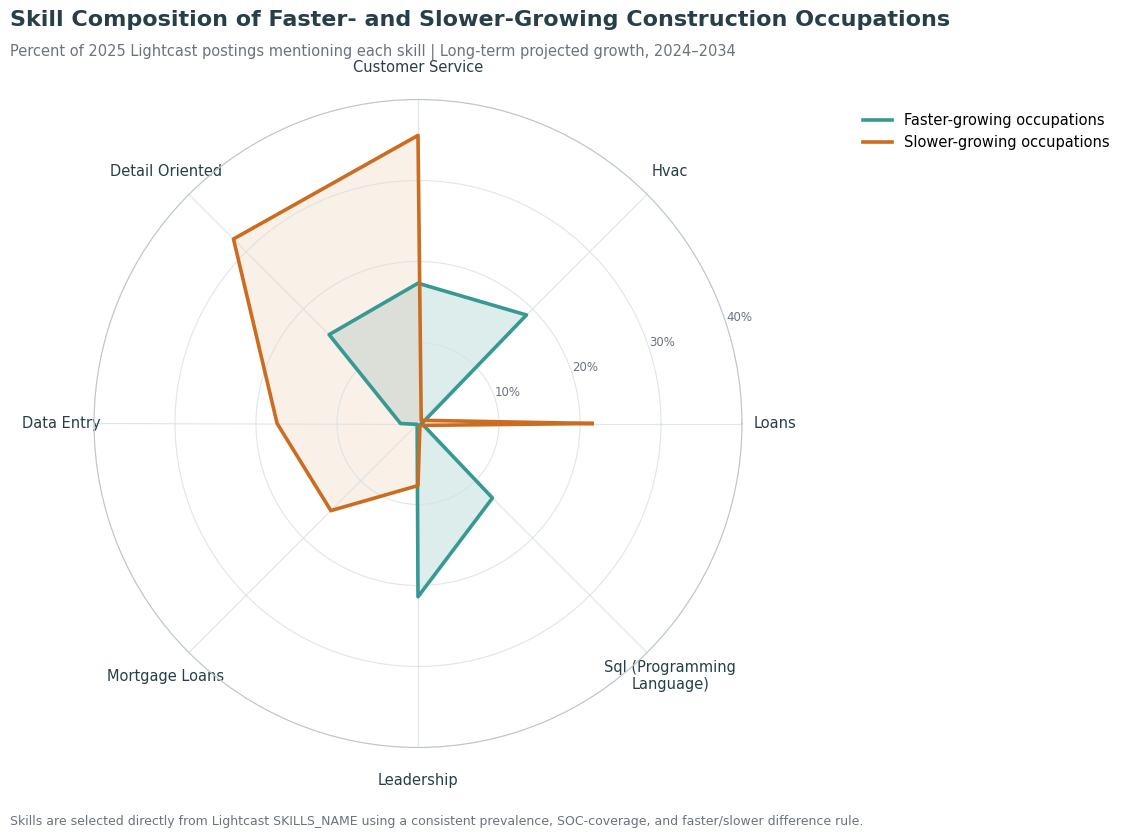

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Construction.png


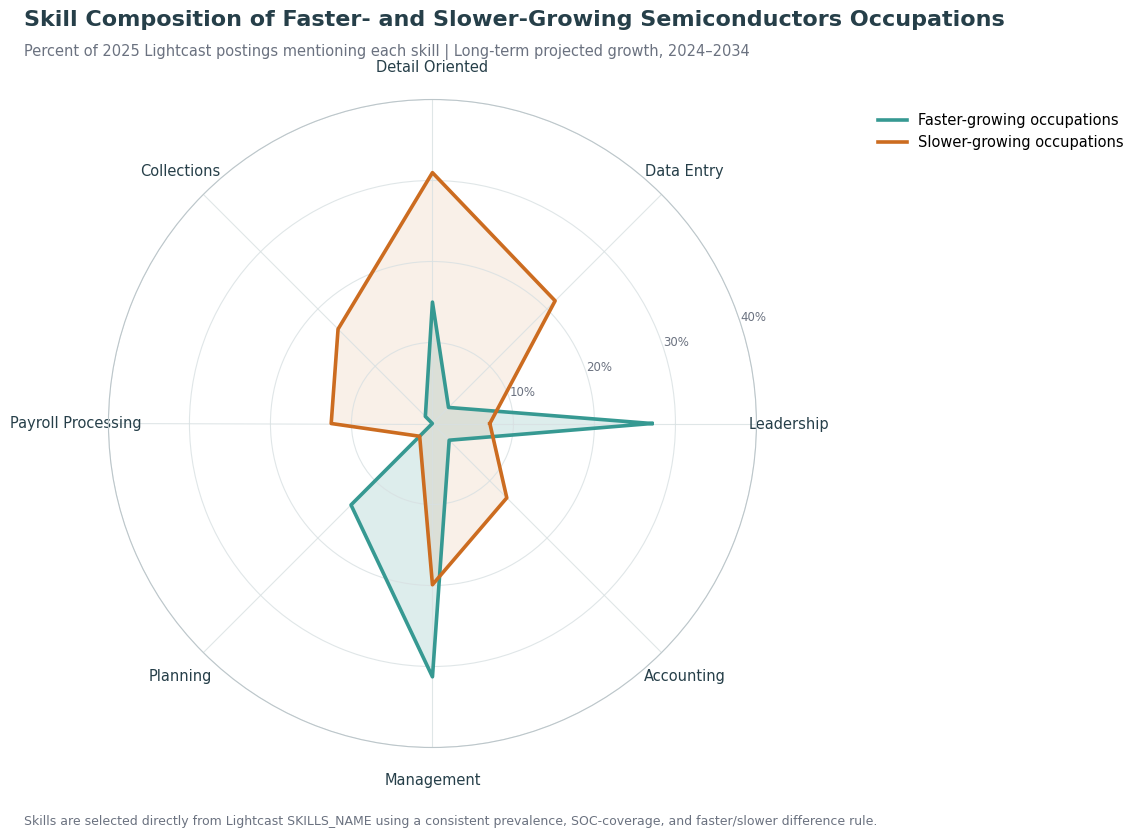

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Semiconductors.png


In [10]:
# ============================================================
# 10. PUBLICATION RADAR FIGURES
# ============================================================

RADAR_FILES = {}

for sector in SECTOR_ORDER:
    chart = radar_data[
        radar_data["Sector"].eq(sector)
    ].copy()

    if chart.empty:
        print(f"No radar data for {sector}.")
        continue

    labels = [
        "\n".join(
            __import__("textwrap").wrap(
                str(value),
                width=22,
                break_long_words=False,
            )
        )
        for value in chart["Skill"]
    ]

    faster = (
        chart["Faster-growing occupations"] * 100
    ).tolist()

    slower = (
        chart["Slower-growing occupations"] * 100
    ).tolist()

    angles = np.linspace(
        0,
        2 * np.pi,
        len(labels),
        endpoint=False,
    ).tolist()

    angles += [angles[0]]
    faster += [faster[0]]
    slower += [slower[0]]

    max_value = max(max(faster), max(slower))
    radial_max = max(30, int(np.ceil(max_value / 10) * 10))
    radial_max = min(radial_max, 100)

    fig = plt.figure(
        figsize=(12, 9),
        facecolor="white",
    )

    # Reserve a clean right-side column for the legend.
    ax = fig.add_axes(
        [0.08, 0.12, 0.68, 0.72],
        polar=True,
    )

    ax.set_facecolor("white")

    ax.plot(
        angles,
        faster,
        color=FASTER_COLOR,
        linewidth=2.6,
        label="Faster-growing occupations",
    )

    ax.fill(
        angles,
        faster,
        color=FASTER_COLOR,
        alpha=0.17,
    )

    ax.plot(
        angles,
        slower,
        color=SLOWER_COLOR,
        linewidth=2.6,
        label="Slower-growing occupations",
    )

    ax.fill(
        angles,
        slower,
        color=SLOWER_COLOR,
        alpha=0.10,
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        labels,
        fontsize=10.5,
        color="#263F49",
    )
    ax.tick_params(axis="x", pad=13)

    ax.set_ylim(0, radial_max)

    tick_values = np.linspace(0, radial_max, 5)[1:]
    ax.set_yticks(tick_values)
    ax.set_yticklabels(
        [f"{value:.0f}%" for value in tick_values],
        fontsize=8.5,
        color="#6B7280",
    )
    ax.set_rlabel_position(18)

    ax.grid(
        color="#D8E0E2",
        linewidth=0.8,
        alpha=0.80,
    )

    ax.spines["polar"].set_color("#BCC6CA")

    fig.text(
        0.08,
        0.94,
        (
            "Skill Composition of Faster- and Slower-Growing "
            f"{sector} Occupations"
        ),
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
        color="#263F49",
    )

    fig.text(
        0.08,
        0.902,
        (
            "Percent of 2025 Lightcast postings mentioning each skill "
            "| Long-term projected growth, 2024–2034"
        ),
        ha="left",
        va="top",
        fontsize=10.5,
        color="#6B7280",
    )

    handles, legend_labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.78, 0.84),
        frameon=False,
        fontsize=10.5,
    )

    fig.text(
        0.08,
        0.035,
        (
            "Skills are selected directly from Lightcast SKILLS_NAME using "
            "a consistent prevalence, SOC-coverage, and faster/slower "
            "difference rule."
        ),
        ha="left",
        fontsize=9,
        color="#6B7280",
    )

    safe_sector = (
        sector
        .replace(
            "Healthcare and Social Assistance",
            "Healthcare_and_Social_Assistance",
        )
        .replace(" ", "_")
    )

    output_png = (
        OUTPUT_FOLDER
        / f"Figure_Lightcast_Skill_Composition_{safe_sector}.png"
    )

    plt.savefig(
        output_png,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    RADAR_FILES[sector] = output_png
    print("Saved:", output_png)


## 11. Supporting software skills

Software products are intentionally excluded from the main radar. They are still useful employer-demand information, so the notebook exports the most prevalent software skills separately for each sector and growth group.


In [11]:
# ============================================================
# 11. TOP SOFTWARE SKILLS BY SECTOR / GROWTH GROUP
# ============================================================

software_rows = []

for sector in SECTOR_ORDER:
    for group in [
        "Faster-growing occupations",
        "Slower-growing occupations",
    ]:
        total = posting_totals[(sector, group)]

        if total == 0:
            continue

        skills = {
            key[2]
            for key in software_posting_counts
            if key[0] == sector and key[1] == group
        }

        rows = []

        for skill in skills:
            count = software_posting_counts[(sector, group, skill)]
            rows.append(
                {
                    "Sector": sector,
                    "Growth Group": group,
                    "Software Skill": display_skill(skill),
                    "Posting Count": count,
                    "Posting Share": count / total,
                }
            )

        if rows:
            top = (
                pd.DataFrame(rows)
                .sort_values("Posting Share", ascending=False)
                .head(10)
            )
            software_rows.append(top)

software_summary = (
    pd.concat(software_rows, ignore_index=True)
    if software_rows
    else pd.DataFrame()
)

display(software_summary)


,Sector,Growth Group,Software Skill,Posting Count,Posting Share
0,Healthcare and Social Assistance,Faster-growing occupations,Sql (Programming Language),425,0.074653
1,Healthcare and Social Assistance,Faster-growing occupations,Microsoft Excel,396,0.069559
2,Healthcare and Social Assistance,Faster-growing occupations,Microsoft Office,358,0.062884
3,Healthcare and Social Assistance,Faster-growing occupations,Python (Programming Language),348,0.061128
4,Healthcare and Social Assistance,Faster-growing occupations,Dashboard,224,0.039347
5,Healthcare and Social Assistance,Faster-growing occupations,Microsoft Outlook,213,0.037414
6,Healthcare and Social Assistance,Faster-growing occupations,Microsoft Powerpoint,200,0.035131
7,Healthcare and Social Assistance,Faster-growing occupations,Power Bi,199,0.034955
8,Healthcare and Social Assistance,Faster-growing occupations,Tableau (Business Intelligence Software),195,0.034253
9,Healthcare and Social Assistance,Faster-growing occupations,Sap Applications,156,0.027402


## 12. Export

The workbook contains:

- **Radar Data** — exact values plotted in the figures;
- **Skill Selection QA** — counts and thresholds used in the selection process;
- one **Skills** sheet per sector showing every candidate skill, prevalence, SOC coverage, eligibility, and whether it was selected;
- **Software Skills** — separate supporting software table; and
- **Selected Occupations** — faster/slower occupation groups used in the analysis.

This makes the figures fully traceable to the underlying Lightcast posting data.


In [12]:
# ============================================================
# 12. EXPORT
# ============================================================

with pd.ExcelWriter(
    OUTPUT_WORKBOOK,
    engine="openpyxl",
) as writer:
    radar_data.to_excel(
        writer,
        sheet_name="Radar Data",
        index=False,
    )

    skill_selection_qa.to_excel(
        writer,
        sheet_name="Skill Selection QA",
        index=False,
    )

    software_summary.to_excel(
        writer,
        sheet_name="Software Skills",
        index=False,
    )

    skill_sheet_names = {
        "Healthcare and Social Assistance": "Skills Healthcare",
        "Manufacturing": "Skills Manufacturing",
        "Construction": "Skills Construction",
        "Semiconductors": "Skills Semiconductor",
    }

    for sector, dataframe in skill_selection_tables.items():
        dataframe.to_excel(
            writer,
            sheet_name=skill_sheet_names[sector],
            index=False,
        )

    occ_sheet_names = {
        "Healthcare and Social Assistance": "Occ Healthcare",
        "Manufacturing": "Occ Manufacturing",
        "Construction": "Occ Construction",
        "Semiconductors": "Occ Semiconductor",
    }

    for (horizon, sector), dataframe in selected_occupation_tables.items():
        if horizon != PRIMARY_HORIZON:
            continue

        dataframe.to_excel(
            writer,
            sheet_name=occ_sheet_names[sector],
            index=False,
        )

    for worksheet in writer.book.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions
        worksheet.sheet_view.showGridLines = False

print("Saved workbook:", OUTPUT_WORKBOOK)

print("\nPublication figures:")
for sector, path in RADAR_FILES.items():
    print(f"  {sector}: {path}")


Saved workbook: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Sector_Skills_Lightcast_Published.xlsx

Publication figures:
  Healthcare and Social Assistance: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Healthcare_and_Social_Assistance.png
  Manufacturing: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Manufacturing.png
  Construction: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Skills Radar\Figure_Lightcast_Skill_Composition_Construction.png
  Semiconductors: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Sector Sk